# Palace CPW Simulation — Lumped Ports

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure with **lumped ports**.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Define GSG electrode

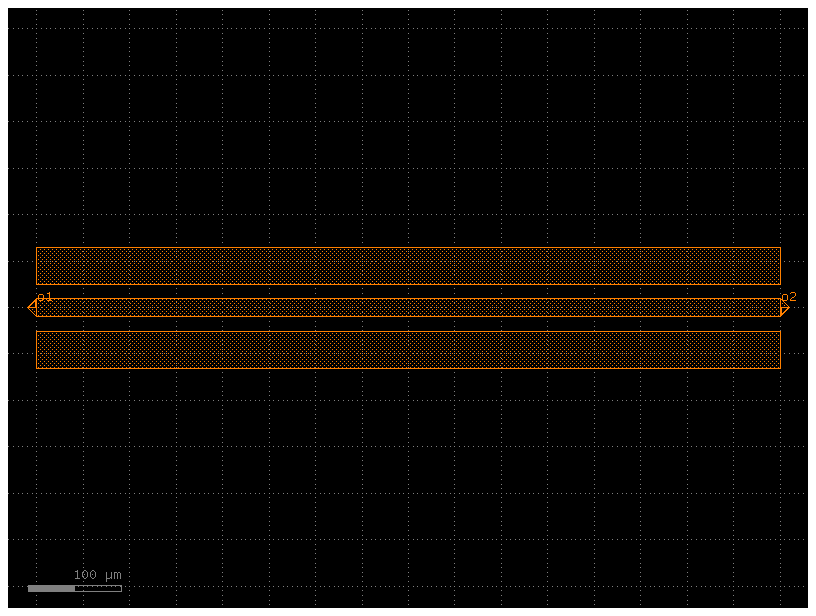

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK

PDK.activate()


@gf.cell
def gsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSG (Ground-Signal-Ground) electrode.

    Args:
        length: horizontal length of the electrodes
        s_width: width of the signal (center) electrode
        g_width: width of the ground electrodes
        gap_width: gap between signal and ground electrodes
        layer: layer for the metal
    """
    c = gf.Component()

    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))

    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)

    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))

    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )

    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )

    return c


c = gsg_electrode()
cc = c.copy()
cc.draw_ports()
cc

### Configure simulation

In [2]:
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-cpw-lumped")
sim.set_geometry(c)
sim.set_stack(substrate_thickness=2.0, air_above=100.0, air_below=100.0)

# CPW lumped ports — offset defaults to length/2 (flush with conductor edge)
sim.add_cpw_port("o1", layer="topmetal2", s_width=20, gap_width=15, excited=True)
sim.add_cpw_port("o2", layer="topmetal2", s_width=20, gap_width=15, excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

print(sim.validate_config())

Validation: PASSED


### Generate mesh

In [3]:
sim.mesh(
    preset="default",
    # refined_mesh_size=2.0,
    # max_mesh_size=40.0,
    # fmax=150e9,
    margin_x=50.0,
    margin_y=0,
)

Mesh Summary
Dimensions: 900.0 x 130.0 x 218.3 µm
Nodes:      9,361
Elements:   69,934
Tetrahedra: 48,616
Edge length: 0.40 - 130.86 µm
Quality:    0.487 (min: 0.002)
SICN:       0.537 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (12):
  - topmetal2_xy [4]
  - topmetal2_z [5]
  - P1_E0 [6]
  - P1_E1 [7]
  - P2_E0 [8]
  - P2_E1 [9]
  - SiO2__None [10]
  - SiO2__passive [11]
  - SiO2__air [12]
  - passive__None [13]
  - air__passive [14]
  - air__None [15]
----------------------------------------
Mesh:   palace-sim-cpw-lumped/palace.msh

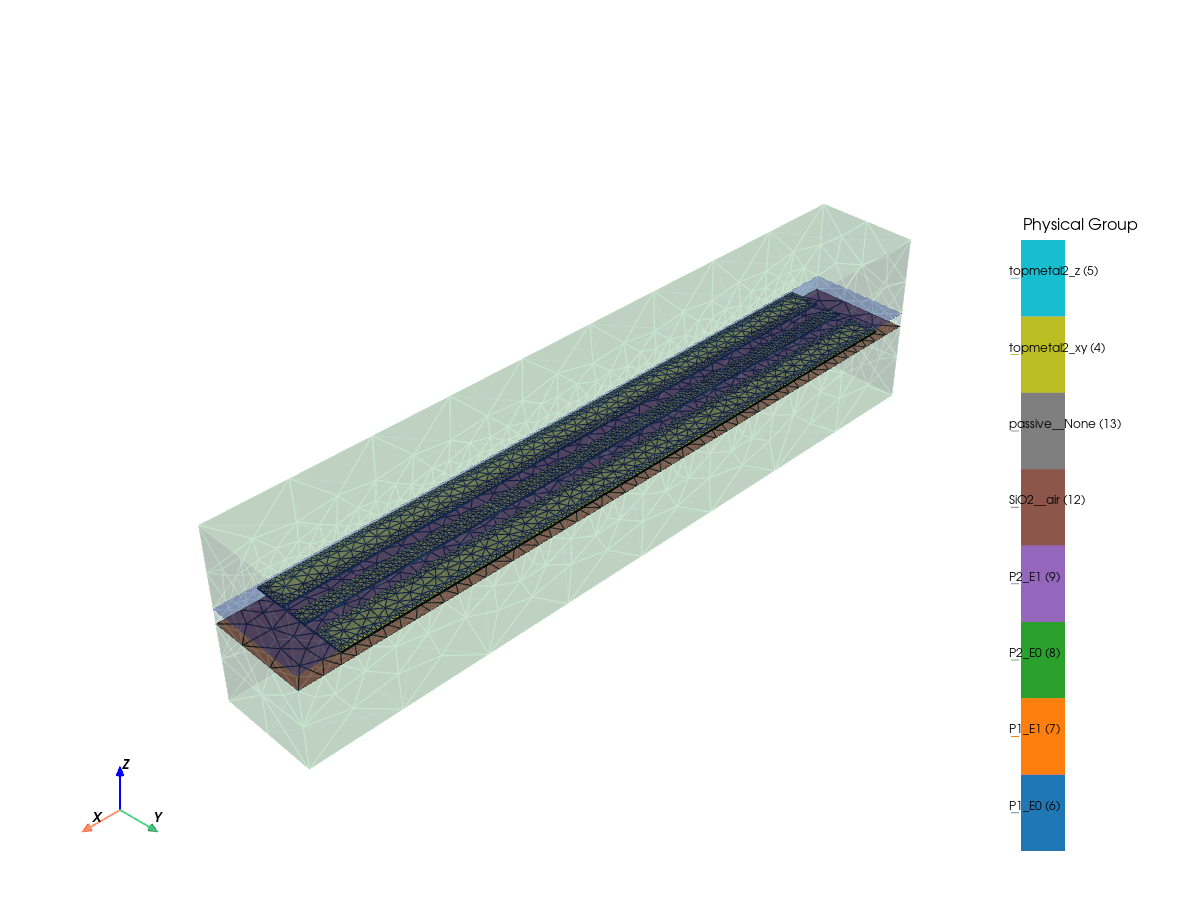

In [4]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

### Run simulation

In [5]:
sim.write_config()
results = sim.run()

  palace-d9c962ae  completed  1m 56s


Extracting results.tar.gz...
Downloaded 10 files to sim-data-palace-d9c962ae


### Plot S-parameters

In [6]:
results.plot_interactive()

Port mapping: Port 1: o1, Port 2: o2


In [7]:
results.plot_interactive(phase=True)

Port mapping: Port 1: o1, Port 2: o2
